In [1]:
"""nb4_designed_sequence — reproduces the two designed-sequence main figures.

Loads cached CSVs/NPZs from data/cache/designed_sequence/ and produces:
  - figures/synthetic.png        (pps top, arcplot + inset bottom)
  - figures/strand_displacement.png (mut-rates top, simplified PP panel below,
                                     schematic image right)

Run from the repo root:
    python notebooks/nb4_designed_sequence.py

To regenerate the cached data (when fits change):
    python notebooks/_regenerate_cache_nb4.py

Or set RECOMPUTE = True below to regenerate inline before plotting.
"""

'nb4_designed_sequence — reproduces the two designed-sequence main figures.\n\nLoads cached CSVs/NPZs from data/cache/designed_sequence/ and produces:\n  - figures/synthetic.png        (pps top, arcplot + inset bottom)\n  - figures/strand_displacement.png (mut-rates top, simplified PP panel below,\n                                     schematic image right)\n\nRun from the repo root:\n    python notebooks/nb4_designed_sequence.py\n\nTo regenerate the cached data (when fits change):\n    python notebooks/_regenerate_cache_nb4.py\n\nOr set RECOMPUTE = True below to regenerate inline before plotting.\n'

In [ ]:
import argparse #lets you handle command-line arguments (options you pass when running the script)
import pathlib #provides an object-oriented interface for working with filesystem paths (files and directories)
import subprocess #allows you to spawn new processes, connect to their input/output/error pipes, and obtain their return codes (used for running commands from within Python)
import sys # gives access to system-related information
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Arc, Patch
from matplotlib.lines import Line2D

#collect the path of the repository
try:
    REPO = pathlib.Path(__file__).resolve().parents[2]
except NameError:
    _p = pathlib.Path.cwd().resolve()
    REPO = next(p for p in [_p, *_p.parents] if (p / 'merge_rna').is_dir())

def _parse_args():
    p = argparse.ArgumentParser(description='Plot nb4 designed-sequence figures')
    p.add_argument('--cache-dir', default=None,
                   help='Override cache directory (default: data/cache/designed_sequence)')
    p.add_argument('--fig-out', default=None,
                   help='Override figures output directory (default: <cache>/figures)')
    args, _ = p.parse_known_args()
    return args

_ARGS = _parse_args()

def _relpath(path):
    try:
        return str(pathlib.Path(path).resolve().relative_to(REPO))
    except Exception:
        return str(path)

CACHE = pathlib.Path(_ARGS.cache_dir) if _ARGS.cache_dir else REPO / 'data' / 'cache' / 'designed_sequence'
FIG_OUT = pathlib.Path(_ARGS.fig_out) if _ARGS.fig_out else CACHE / 'figures'
FIG_OUT.mkdir(parents=True, exist_ok=True)


def _show_or_note(path):
    try:
        get_ipython()
        from IPython.display import display, Image
        display(Image(str(path)))
    except NameError:
        print(f"  saved -> {_relpath(path)}")

FileExistsError: [Errno 17] File exists: '/run/user/1000/jupyter/runtime/kernel-v36d7e6d77983ec03fc9c1f6c86efbb3d957113dec.json'

In [8]:
RECOMPUTE = False  # set True to regenerate cache from fits before plotting

SYNTH_POPS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
ARC_THRESHOLD = 0.01
ARC_MAX_LW = 3.0

# Strand-displacement panel colours
COLOR_TURNER = '#607D8B'
COLOR_ANDRONESCU = '#C62828'

if RECOMPUTE:
    print("Regenerating cache...")
    subprocess.run(
        [sys.executable, str(REPO / 'notebooks' / '_regenerate_cache_nb4.py')],
        check=True,
    )

In [12]:
synth_pp = pd.read_csv(CACHE / 'synthetic_pp_curves.csv')
synth_inset = pd.read_csv(CACHE / 'synthetic_inset_table.csv')
d_arc = np.load(CACHE / 'synthetic_arcplot_extremes.npz', allow_pickle=True)
sd_mut = pd.read_csv(CACHE / 'strand_disp_mut_rates.csv')
sd_pp = pd.read_csv(CACHE / 'strand_disp_pp_curves.csv')

bpp_pop0 = d_arc['bpp_pop0']
bpp_pop1 = d_arc['bpp_pop1']
seq_synth = str(d_arc['seq'])
indices_helix1 = d_arc['indices_helix1']
indices_helix2 = d_arc['indices_helix2']

In [13]:

def _plot_arcs_below(ax, bpp_matrix, sequence, color, label,
                     threshold=ARC_THRESHOLD, max_linewidth=ARC_MAX_LW):
    """Draw BPP arcs below the baseline; linewidth proportional to probability."""
    from matplotlib.colors import to_rgba
    rgba = to_rgba(color)
    n = len(sequence)
    for i in range(n):
        for j in range(i + 1, n):
            prob = bpp_matrix[i, j]
            if prob > threshold:
                center_x = (i + j) / 2.0
                width = j - i
                ax.add_patch(Arc(
                    xy=(center_x, 0),
                    width=width,
                    height=width,
                    angle=0, theta1=180, theta2=360,
                    edgecolor=rgba[:3] + (1.0,),
                    linewidth=max_linewidth * prob,
                    fill=False, alpha=0.7, zorder=2,
                    label=label if i == 0 and j == 1 else "",
                ))

In [14]:

print("Plotting synthetic figure...")
np.random.seed(0)
colors_synth = plt.cm.inferno(np.linspace(0, 1, len(SYNTH_POPS) + 1))

fig = plt.figure(figsize=(6, 6), dpi=300)
gs = GridSpec(2, 1, height_ratios=[1, 1], hspace=0)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

for idx, pop1 in enumerate(SYNTH_POPS):
    color = colors_synth[idx]
    df_pop = synth_pp[synth_pp['pop1'] == pop1].sort_values('pos')
    ax_top.plot(df_pop['pos'].values, df_pop['pp'].values,
                label=f'{pop1:.2f}', color=color)

ax_top.fill_betweenx([0, 1], indices_helix1[0], indices_helix1[-1], color='yellow', alpha=0.3)
ax_top.fill_betweenx([0, 1], indices_helix2[0], indices_helix2[-1], color='green', alpha=0.2)
ax_top.legend(title='Target Pop.\nfor Helix 1', loc='upper left')
ax_top.grid(axis='both', linestyle='--', alpha=0.7)
ax_top.set_ylim(0, 1)
ax_top.set_ylabel('Pairing Probability')
ax_top.set_title('Fit on data with varying populations')
plt.setp(ax_top.get_xticklabels(), visible=False)
ax_top.text(0.98, 0.95, 'a', transform=ax_top.transAxes, fontsize=16,
            fontweight='bold', va='top', ha='right')

# Arc plot
n = len(seq_synth)
ax_bot.plot([-1, n], [0, 0], 'k-', linewidth=1.0)
_plot_arcs_below(ax_bot, bpp_pop0, seq_synth,
                 color=colors_synth[0], label='pop1=0.00')
_plot_arcs_below(ax_bot, bpp_pop1, seq_synth,
                 color=colors_synth[len(SYNTH_POPS) - 1], label='pop1=1.00')
ax_bot.fill_betweenx([-n, 0], indices_helix1[0], indices_helix1[-1], color='yellow', alpha=0.3)
ax_bot.fill_betweenx([-n, 0], indices_helix2[0], indices_helix2[-1], color='green', alpha=0.2)
ax_bot.set_ylim(-(n * 0.6), 0)
ax_bot.set_ylabel('Arc Plot')
ax_bot.set_xlabel('Nucleotide Position')
ax_bot.set_yticks([])
ax_bot.grid(axis='x', linestyle='--', alpha=0.7)
ax_bot.legend(handles=[
    Patch(facecolor=colors_synth[len(SYNTH_POPS) - 1], label='Helix 1 fully formed', alpha=0.7),
    Patch(facecolor=colors_synth[0], label='Helix 2 fully formed', alpha=0.7),
], loc='lower right')
ax_bot.text(0.98, 0.95, 'b', transform=ax_bot.transAxes, fontsize=16,
            fontweight='bold', va='top', ha='right')

# Inset
ax_inset = ax_bot.inset_axes([0.05, 0.2, 0.45, 0.6])
ax_inset.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax_inset.plot([0, 1], [1, 0], 'k--', alpha=0.3)
ax_inset.plot(synth_inset['pop1'], synth_inset['median_pp_helix1'],
              'o', color='gold', label='Helix 1', markersize=6)
ax_inset.plot(synth_inset['pop1'], synth_inset['median_pp_helix2'],
              'o', color='darkgreen', label='Helix 2', markersize=6)
ax_inset.set_aspect('equal', 'box')
ax_inset.set_xlim(-0.01, 1.01)
ax_inset.set_ylim(-0.01, 1.01)
ax_inset.set_xlabel('Target Pop. (Helix 1)', fontsize=10)
ax_inset.set_ylabel('Obtained Pop.', fontsize=10)
ax_inset.tick_params(axis='both', which='major', labelsize=8)
ax_inset.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax_inset.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax_inset.legend(fontsize=8, loc='lower center')
ax_inset.text(0.95, 0.95, 'c', transform=ax_inset.transAxes, fontsize=12,
              fontweight='bold', va='top', ha='right')

plt.tight_layout()
out_path = FIG_OUT / 'synthetic.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.close('all')
_show_or_note(out_path)
print(f"  saved: {_relpath(out_path)}")

Plotting synthetic figure...


NotADirectoryError: [Errno 20] Not a directory: '/run/user/1000/jupyter/runtime/kernel-v361b042602fb80bb9e1c9b8b7dfe9d46fe62be880.json/synthetic.png'

Plotting strand-displacement figure...


/var/folders/yv/pbz2ynzx0tz1cpq7clsqk9mw0000gn/T/ipykernel_82485/1424739552.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


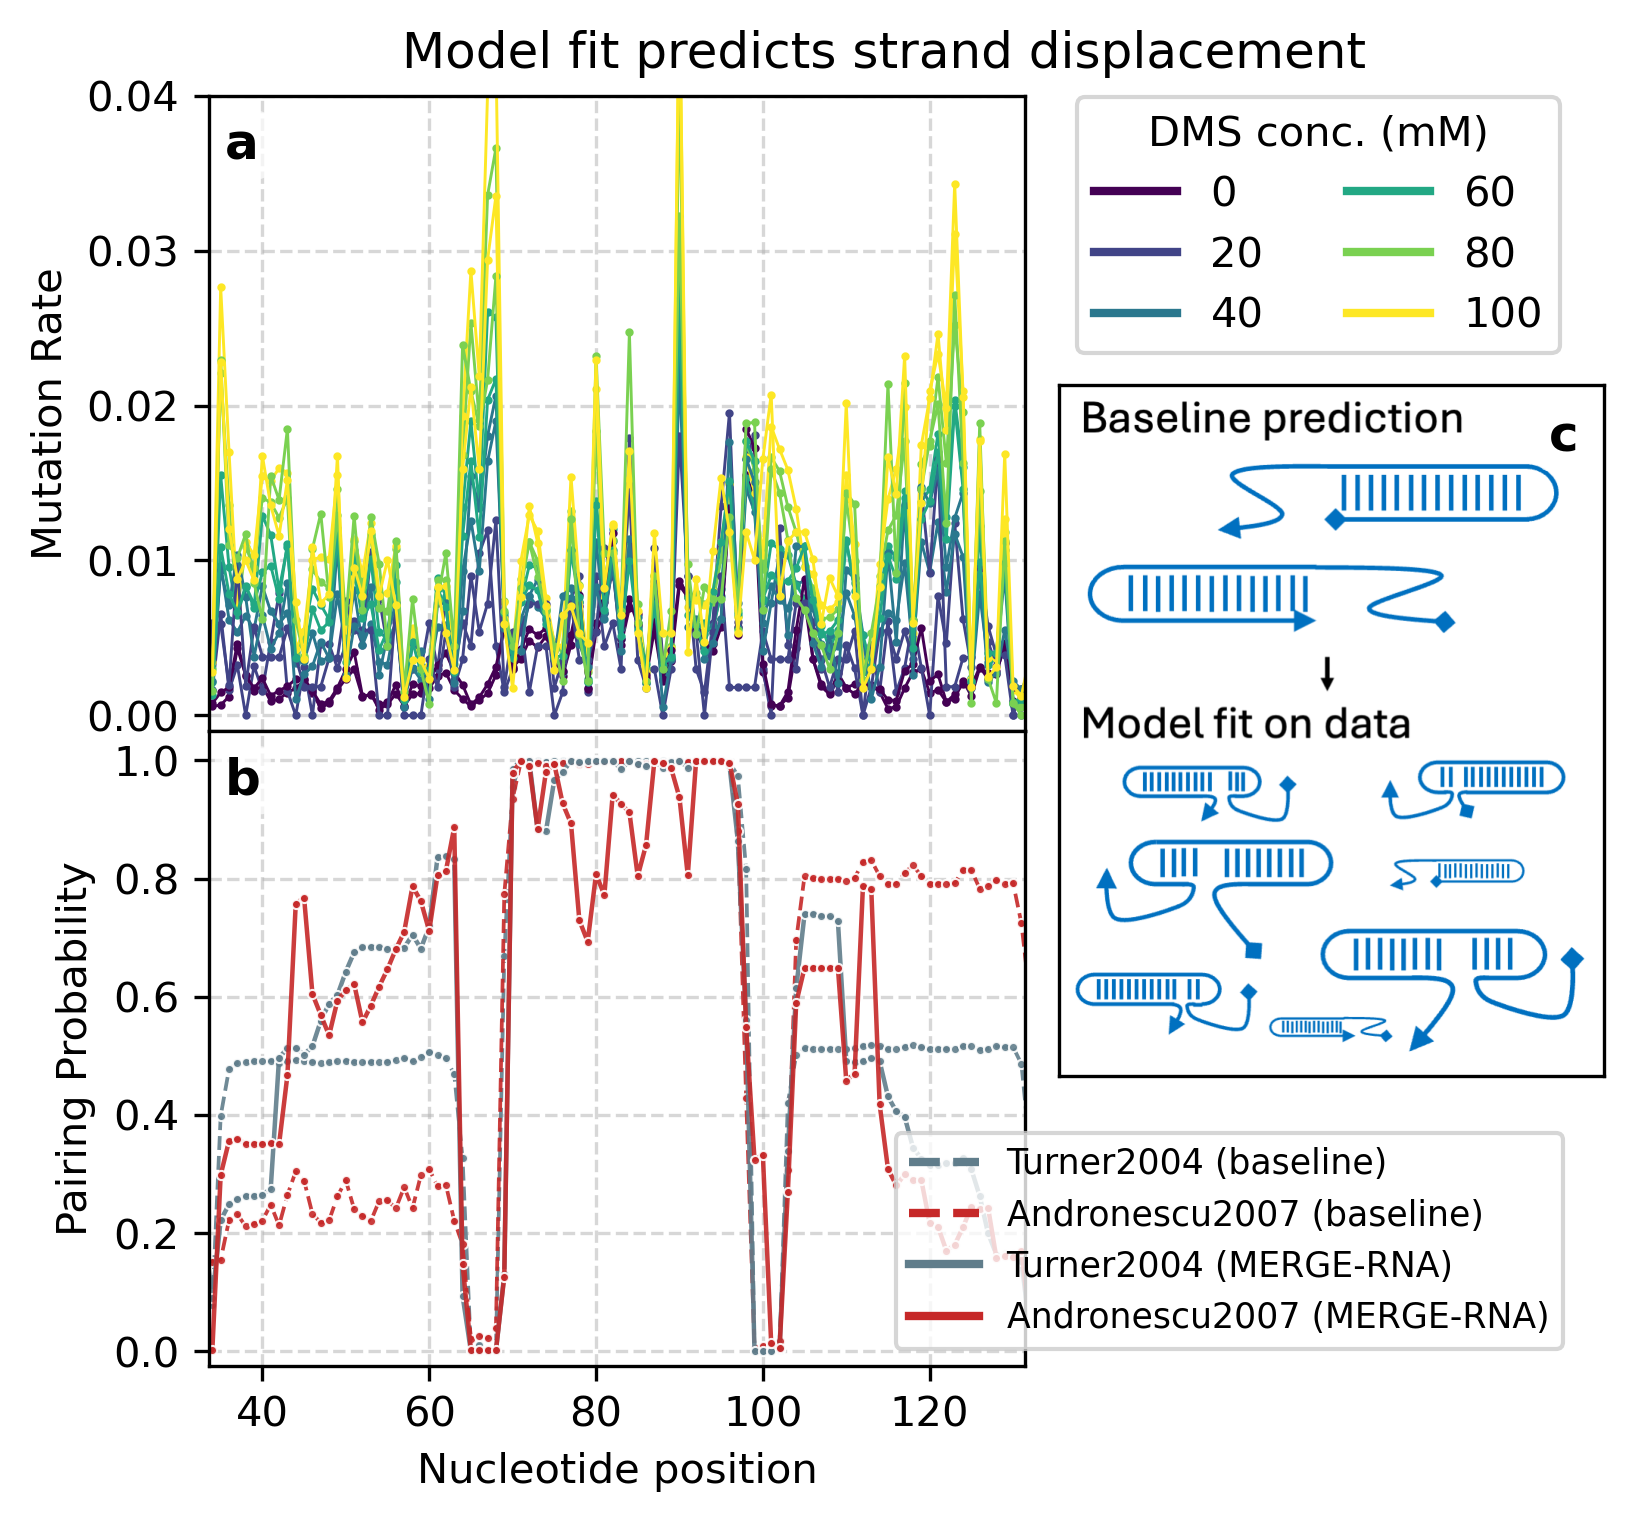

  saved: data/cache/designed_sequence/figures/strand_displacement.png

Done. Figures written to data/cache/designed_sequence/figures


In [7]:

print("Plotting strand-displacement figure...")

style_baseline = dict(marker='o', ms=2.2, ls='--', lw=0.9, alpha=0.9,
                      markeredgecolor='white', markeredgewidth=0.5)
style_merge = dict(marker='o', ms=2.2, ls='-', lw=1.08, alpha=0.9,
                   markeredgecolor='white', markeredgewidth=0.5)

fig = plt.figure(figsize=(6, 5.5), dpi=300)
gs = GridSpec(2, 2, width_ratios=[1.5, 1], height_ratios=[1, 1],
              wspace=0.05, hspace=0.0)
ax_mut = fig.add_subplot(gs[0, 0])
ax_pp = fig.add_subplot(gs[1, 0], sharex=ax_mut)
ax_img = fig.add_subplot(gs[:, 1])

label_kw = dict(ha='left', va='top', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          alpha=0.7, edgecolor='none'))

# Panel a: mutation rates
concs_sorted = sorted(sd_mut['conc_mM'].unique())
n_concs = len(concs_sorted)
colors_mut = plt.cm.viridis(np.linspace(0, 1, n_concs))
conc_color = {c: colors_mut[i] for i, c in enumerate(concs_sorted)}

for (rep, conc), grp in sd_mut.groupby(['rep', 'conc_mM']):
    grp = grp.sort_values('pos')
    ax_mut.plot(grp['pos'].values, grp['mut_rate'].values,
                color=conc_color[conc], marker='o', ms=1, ls='-', lw=0.7)
ax_mut.set_ylabel('Mutation Rate')
ax_mut.set_ylim(-0.001, 0.04)
ax_mut.grid(True, ls='--', alpha=0.5)
ax_mut.tick_params(axis='x', labelbottom=False)
xlims = ax_mut.get_xlim()
ax_mut.set_xlim(xlims[0] + 22, xlims[1] - 22)
legend_handles_mut = [
    Line2D([0], [0], color=conc_color[c], lw=2, label=str(c))
    for c in concs_sorted
]
ax_mut.legend(handles=legend_handles_mut, ncol=2, loc='upper right',
              bbox_to_anchor=(1.68, 1.03), title='DMS conc. (mM)')
ax_mut.text(0.02, 0.96, 'a', transform=ax_mut.transAxes, **label_kw)

# Panel b: pairing probabilities (Baseline dashed, MERGE solid)
pos_vals = sd_pp['pos'].values
ax_pp.plot(pos_vals, sd_pp['baseline_turner'].values,
           color=COLOR_TURNER, label='Turner2004 (baseline)', **style_baseline)
ax_pp.plot(pos_vals, sd_pp['baseline_andronescu'].values,
           color=COLOR_ANDRONESCU, label='Andronescu2007 (baseline)', **style_baseline)
ax_pp.plot(pos_vals, sd_pp['merge_turner'].values,
           color=COLOR_TURNER, label='Turner2004 (MERGE-RNA)', **style_merge)
ax_pp.plot(pos_vals, sd_pp['merge_andronescu'].values,
           color=COLOR_ANDRONESCU, label='Andronescu2007 (MERGE-RNA)', **style_merge)
ax_pp.set_ylim(-0.025, 1.05)
ax_pp.set_ylabel('Pairing Probability')
ax_pp.set_xlabel('Nucleotide position')
ax_pp.grid(True, ls='--', alpha=0.5)
legend_handles_pp = [
    Line2D([0], [0], color=COLOR_TURNER,     lw=2, ls='--', label='Turner2004 (baseline)'),
    Line2D([0], [0], color=COLOR_ANDRONESCU, lw=2, ls='--', label='Andronescu2007 (baseline)'),
    Line2D([0], [0], color=COLOR_TURNER,     lw=2, ls='-',  label='Turner2004 (MERGE-RNA)'),
    Line2D([0], [0], color=COLOR_ANDRONESCU, lw=2, ls='-',  label='Andronescu2007 (MERGE-RNA)'),
]
ax_pp.legend(handles=legend_handles_pp, loc='lower right',
             bbox_to_anchor=(1.68, 0.0), fontsize='small')
ax_pp.text(0.02, 0.96, 'b', transform=ax_pp.transAxes, **label_kw)

# Panel c: schematic image
schematic_path = CACHE / 'schematic_result.png'
if schematic_path.exists():
    img = plt.imread(str(schematic_path))
    ax_img.imshow(img)
ax_img.set_xticks([])
ax_img.set_yticks([])
ax_img.text(0.9, 0.96, 'c', transform=ax_img.transAxes, **label_kw)

fig.suptitle('Model fit predicts strand displacement', fontsize=12, y=0.92)
plt.tight_layout()
out_path = FIG_OUT / 'strand_displacement.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.close('all')
_show_or_note(out_path)
print(f"  saved: {_relpath(out_path)}")

print(f"\nDone. Figures written to {_relpath(FIG_OUT)}")